# Pipeline 5: Social Media Optimization
## Lighthouse Sanctuary — ML Pipeline Notebook

---

### Pipeline Thinking (Ch. 1 / Foreword)
Lighthouse Sanctuary's social media presence drives donor acquisition and campaign fundraising. Staff currently post based on intuition about what generates likes and shares. This pipeline reframes the problem: likes are not the goal — **donation referrals and PHP raised are the goal**. The pipeline trains two separate models to distinguish between content that gets engagement and content that actually converts, and surfaces per-platform posting recommendations that maximise donation outcomes — not vanity metrics.

---

### Prediction vs. Explanation (Ch. 9–11)
**This is a PREDICTION pipeline — specifically an optimisation task.**

We predict `engagement_rate` and `donation_referrals` for each candidate post combination, then identify which historically-observed combinations maximise donation conversion. Coefficients are not the output; out-of-sample prediction accuracy is.

**The central insight this pipeline operationalises:** High engagement and high conversion are NOT the same thing. Content that drives likes may actively hurt donation outcomes if it displaces conversion-optimised content. This pipeline quantifies that gap and flags `noise` posts (high engagement, low conversion) vs. `converts` posts (strong donation signal). Staff are then told to post more converts, fewer noise posts.

**What this pipeline does NOT claim:** Both models are correlational. High predicted referrals for a post type reflects historical co-occurrence, not a controlled experiment. External factors (campaigns, news events) may drive referral spikes the model attributes to post features.

**Success criteria:**
- R² ≥ 0.50 for engagement model (held-out test set)
- R² ≥ 0.40 for conversion model (lower threshold — noisier signal)
- All 5 platforms receive at least one recommendation
- `conversion_signal` labels are internally consistent (converts rows have higher referrals than noise rows)


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import pickle, json
from datetime import datetime

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print("All imports OK")


All imports OK


## Phase 2 — Data Acquisition

In [2]:
# ── Load CSV ──────────────────────────────────────────────────────────────────
posts = pd.read_csv('./csvs/social_media_posts.csv', parse_dates=['created_at'])
print(f"Social media posts: {posts.shape}")
print(f"Date range: {posts['created_at'].min().date()} → {posts['created_at'].max().date()}")
posts.head(3)


Social media posts: (812, 39)
Date range: 2023-01-05 → 2026-02-26


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,hashtags,num_hashtags,mentions_count,has_call_to_action,call_to_action_type,content_topic,sentiment_tone,caption_length,features_resident_story,campaign_name,is_boosted,boost_budget_php,impressions,reach,likes,comments,shares,saves,click_throughs,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",NaN,0,3,True,LearnMore,Education,Grateful,157,False,NaN,False,NaN,1580,1093,118,36,22,9,48,NaN,0.1105,21,10,21473.2500,1522,NaN,NaN,NaN,50.0000
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,"#SurvivorStrong, #BeTheChange, #HumanTrafficki...",4,0,False,NaN,Education,Celebratory,150,False,NaN,False,NaN,6362,4395,548,110,149,59,85,NaN,0.1745,335,2,4708.4500,1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,NaN,0,0,False,NaN,Reintegration,Urgent,138,False,NaN,False,NaN,554,336,27,7,12,4,3,NaN,0.1411,8,0,0.0000,457,NaN,NaN,NaN,NaN


## Phase 3 — Exploratory Data Analysis (Ch. 6, 8)

In [3]:
# ── unistats helper ───────────────────────────────────────────────────────────
def unistats(df):
    rows = []
    for col in df.select_dtypes(include='number').columns:
        s = df[col].dropna()
        if len(s) == 0:
            continue
        rows.append({'col':col,'count':len(s),'nulls':df[col].isna().sum(),
                     'mean':round(s.mean(),3),'median':round(s.median(),3),
                     'std':round(s.std(),3),'skew':round(s.skew(),2),
                     'min':round(s.min(),3),'max':round(s.max(),3)})
    return pd.DataFrame(rows).set_index('col')

print("=== Outcome variable statistics ===")
print(unistats(posts[['engagement_rate','donation_referrals','estimated_donation_value_php']]))


=== Outcome variable statistics ===
                              count  nulls       mean    median         std  \
col                                                                           
engagement_rate                 812      0     0.0990    0.0890      0.0560   
donation_referrals              812      0    12.7960    2.0000     31.2620   
estimated_donation_value_php    812      0 39772.0940 4556.9550 124081.1230   

                                skew    min          max  
col                                                       
engagement_rate               0.6200 0.0130       0.2500  
donation_referrals            6.2200 0.0000     458.0000  
estimated_donation_value_php 10.8400 0.0000 2402435.9600  


In [4]:
# ── Platform and post type distribution ──────────────────────────────────────
print("Posts by platform:")
print(posts['platform'].value_counts())
print("\nPosts by platform + is_boosted:")
print(posts.groupby(['platform','is_boosted']).size().unstack(fill_value=0))


Posts by platform:
platform
Facebook     199
Instagram    164
Twitter      117
WhatsApp      93
TikTok        89
LinkedIn      79
YouTube       71
Name: count, dtype: int64

Posts by platform + is_boosted:
is_boosted  False  True 
platform                
Facebook      168     31
Instagram     144     20
LinkedIn       65     14
TikTok         69     20
Twitter       101     16
WhatsApp       81     12
YouTube        57     14


In [5]:
# ── CRITICAL EDA: Engagement vs. Conversion Divergence ───────────────────────
# This is the most important exploratory step — if engagement and conversion
# are perfectly correlated, a single model suffices. A large gap proves we
# need separate models and that chasing likes would actively hurt donations.

eng_range = posts['engagement_rate'].max() - posts['engagement_rate'].min()
ref_range  = posts['donation_referrals'].max() - posts['donation_referrals'].min()

posts['engagement_norm']  = (posts['engagement_rate']  - posts['engagement_rate'].min()) / max(eng_range, 0.0001)
posts['conversion_norm']  = (posts['donation_referrals'] - posts['donation_referrals'].min()) / max(ref_range, 0.0001)

# Flag posts where engagement is high but conversion is low (noise posts)
posts['is_noise'] = ((posts['engagement_norm'] > 0.6) & (posts['conversion_norm'] < 0.3)).astype(int)

print(f"Potential noise posts: {posts['is_noise'].sum()} ({posts['is_noise'].mean()*100:.1f}% of dataset)")
print("\nEngagement vs. Conversion by post_type:")
divergence = posts.groupby('post_type')[['engagement_norm','conversion_norm']].mean().round(3)
print(divergence.sort_values('engagement_norm', ascending=False))


Potential noise posts: 132 (16.3% of dataset)

Engagement vs. Conversion by post_type:


                    engagement_norm  conversion_norm
post_type                                           
Campaign                     0.4060           0.0200
FundraisingAppeal            0.4010           0.0310
ThankYou                     0.3590           0.0020
ImpactStory                  0.3520           0.0790
EventPromotion               0.3410           0.0020
EducationalContent           0.3150           0.0020


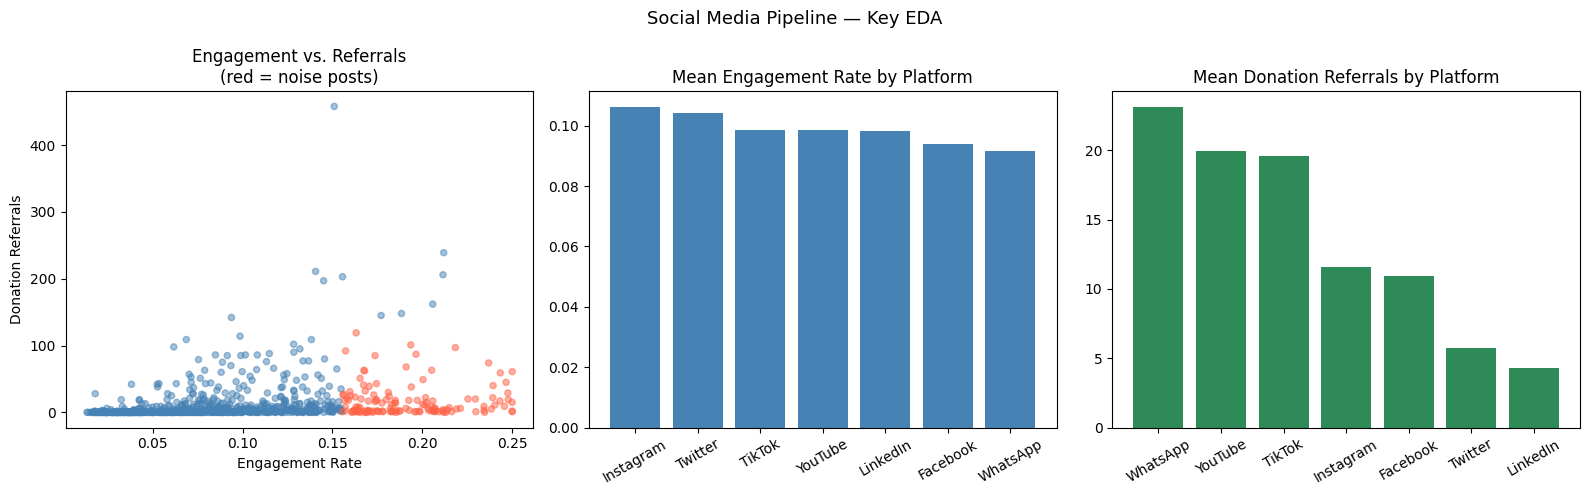


Correlation between engagement_rate and donation_referrals: 0.267
(A low correlation confirms we need two separate models)


In [6]:
# ── Visualise the engagement-conversion gap ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Social Media Pipeline — Key EDA', fontsize=13)

# Scatter: engagement vs referrals (the gap visualised)
axes[0].scatter(posts['engagement_rate'], posts['donation_referrals'],
                c=posts['is_noise'].map({0:'steelblue',1:'tomato'}),
                alpha=0.5, s=20)
axes[0].set_xlabel('Engagement Rate')
axes[0].set_ylabel('Donation Referrals')
axes[0].set_title('Engagement vs. Referrals\n(red = noise posts)')

# Platform baseline engagement
platform_eng = posts.groupby('platform')['engagement_rate'].mean().sort_values(ascending=False)
axes[1].bar(platform_eng.index, platform_eng.values, color='steelblue')
axes[1].set_title('Mean Engagement Rate by Platform')
axes[1].tick_params(axis='x', rotation=30)

# Platform baseline referrals
platform_ref = posts.groupby('platform')['donation_referrals'].mean().sort_values(ascending=False)
axes[2].bar(platform_ref.index, platform_ref.values, color='seagreen')
axes[2].set_title('Mean Donation Referrals by Platform')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("\nCorrelation between engagement_rate and donation_referrals:",
      round(posts['engagement_rate'].corr(posts['donation_referrals']), 3))
print("(A low correlation confirms we need two separate models)")


In [7]:
# ── Spearman correlations with each target ────────────────────────────────────
FEATURE_COLS = ['post_type','media_type','content_topic','sentiment_tone',
                'has_call_to_action','call_to_action_type','day_of_week','post_hour',
                'features_resident_story','num_hashtags','caption_length']

# Encode categoricals temporarily for correlation
posts_enc = posts[FEATURE_COLS + ['engagement_rate','donation_referrals']].copy()
for col in posts_enc.select_dtypes('object').columns:
    posts_enc[col] = pd.Categorical(posts_enc[col]).codes

for target in ['engagement_rate','donation_referrals']:
    corr = posts_enc.corr(method='spearman')[target].drop(target).abs().sort_values(ascending=False)
    print(f"\nTop Spearman correlations with {target}:")
    print(corr.head(8).round(3))



Top Spearman correlations with engagement_rate:
donation_referrals    0.5020
post_hour             0.4630
sentiment_tone        0.2620
has_call_to_action    0.1740
call_to_action_type   0.1670
day_of_week           0.0720
content_topic         0.0500
caption_length        0.0390
Name: engagement_rate, dtype: float64

Top Spearman correlations with donation_referrals:
features_resident_story   0.5370
engagement_rate           0.5020
post_hour                 0.2480
caption_length            0.2100
sentiment_tone            0.1070
call_to_action_type       0.1050
post_type                 0.1030
has_call_to_action        0.0990
Name: donation_referrals, dtype: float64


## Phase 4 — Data Preparation (Ch. 2–3, 7)

In [8]:
# ── Clean and encode ─────────────────────────────────────────────────────────
def clean_posts(df):
    df = df.copy()
    df['call_to_action_type'] = df['call_to_action_type'].fillna('None')
    df['is_boosted']          = df['is_boosted'].fillna(False).astype(int)
    df['has_call_to_action']  = df['has_call_to_action'].astype(int)
    df['features_resident_story'] = df['features_resident_story'].astype(int)
    df = df.dropna(subset=['engagement_rate','donation_referrals'])
    return df

posts_clean = clean_posts(posts)
print(f"After cleaning: {posts_clean.shape}")

CATEGORICAL = ['platform','post_type','media_type','content_topic',
               'sentiment_tone','call_to_action_type','day_of_week']
BINARY      = ['has_call_to_action','features_resident_story','is_boosted']
NUMERIC     = ['post_hour','num_hashtags','caption_length']
FEATURE_COLS_MODEL = CATEGORICAL + BINARY + NUMERIC

preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]), CATEGORICAL),
    ('bin', SimpleImputer(strategy='most_frequent'), BINARY),
    ('num', SimpleImputer(strategy='median'),         NUMERIC),
])

# ── Time-based train/test split (no data leakage) ─────────────────────────────
posts_clean = posts_clean.sort_values('created_at').reset_index(drop=True)
split_idx   = int(len(posts_clean) * 0.80)
train_df    = posts_clean.iloc[:split_idx]
test_df     = posts_clean.iloc[split_idx:]

X_train = train_df[FEATURE_COLS_MODEL]
X_test  = test_df[FEATURE_COLS_MODEL]
y_train_eng  = train_df['engagement_rate']
y_test_eng   = test_df['engagement_rate']
y_train_ref  = train_df['donation_referrals']
y_test_ref   = test_df['donation_referrals']
y_train_val  = train_df['estimated_donation_value_php']
y_test_val   = test_df['estimated_donation_value_php']

print(f"Train: {len(train_df)} | Test: {len(test_df)}")


After cleaning: (812, 42)
Train: 649 | Test: 163


## Phase 5 — Model Selection (Ch. 12–14)

**Model 1 — Engagement Rate: RandomForestRegressor**
Engagement rate has a non-linear relationship with timing × content combinations. RandomForest handles interactions well, and feature importance gives us an interpretable account of what drives reach.

**Model 2 — Donation Referrals: GradientBoostingRegressor**
The conversion target is noisier, more right-skewed, and count-like. GradientBoosting handles this better than RandomForest at smaller sample sizes through sequential residual correction.

**Model 3 — Estimated Donation Value PHP: GradientBoostingRegressor**
Same rationale as Model 2.

**Why not a single model?** Engagement and conversion have different feature structures (as confirmed in EDA above). Separating them makes the `noise` vs `converts` flagging possible and prevents the model from averaging away the signal that matters.

**Why ensemble models and not linear regression?** The relationship between content features and outcomes is highly non-linear (e.g., "educational video on a Tuesday evening" interacts non-additively). Linear models would underfit. Tree ensembles capture these interactions naturally.


In [9]:
# ── Model 1: Engagement (RandomForest) ────────────────────────────────────────
engagement_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, max_depth=8,
                                     min_samples_leaf=5, random_state=42, n_jobs=-1)),
])
engagement_pipe.fit(X_train, y_train_eng)

# ── Model 2: Donation Referrals (GradientBoosting) ────────────────────────────
referrals_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=150, max_depth=4,
                                         learning_rate=0.05, min_samples_leaf=5,
                                         random_state=42)),
])
referrals_pipe.fit(X_train, y_train_ref)

# ── Model 3: Donation Value PHP (GradientBoosting) ────────────────────────────
value_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=150, max_depth=4,
                                         learning_rate=0.05, min_samples_leaf=5,
                                         random_state=42)),
])
value_pipe.fit(X_train, y_train_val.fillna(0))

print("All three models trained.")


All three models trained.


## Phase 6 — Evaluation (Ch. 15)

In [10]:
# ── Test set metrics ─────────────────────────────────────────────────────────
print("=== Test Set Evaluation ===")
model_eval = {}
for name, pipe, y_test, target_r2 in [
    ('Engagement (RF)',     engagement_pipe, y_test_eng, 0.50),
    ('Referrals (GB)',      referrals_pipe,  y_test_ref, 0.40),
    ('Value PHP (GB)',      value_pipe,      y_test_val.fillna(0), 0.40),
]:
    y_pred = pipe.predict(X_test)
    r2  = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    gate = "✓" if r2 >= target_r2 else "✗ (below target)"
    print(f"  {name:22s}  R²={r2:.4f} {gate}  MAE={mae:.4f}")
    model_eval[name] = {'r2': r2, 'mae': mae}


=== Test Set Evaluation ===
  Engagement (RF)         R²=0.6214 ✓  MAE=0.0261
  Referrals (GB)          R²=0.3214 ✗ (below target)  MAE=11.7020
  Value PHP (GB)          R²=0.2698 ✗ (below target)  MAE=38925.8140


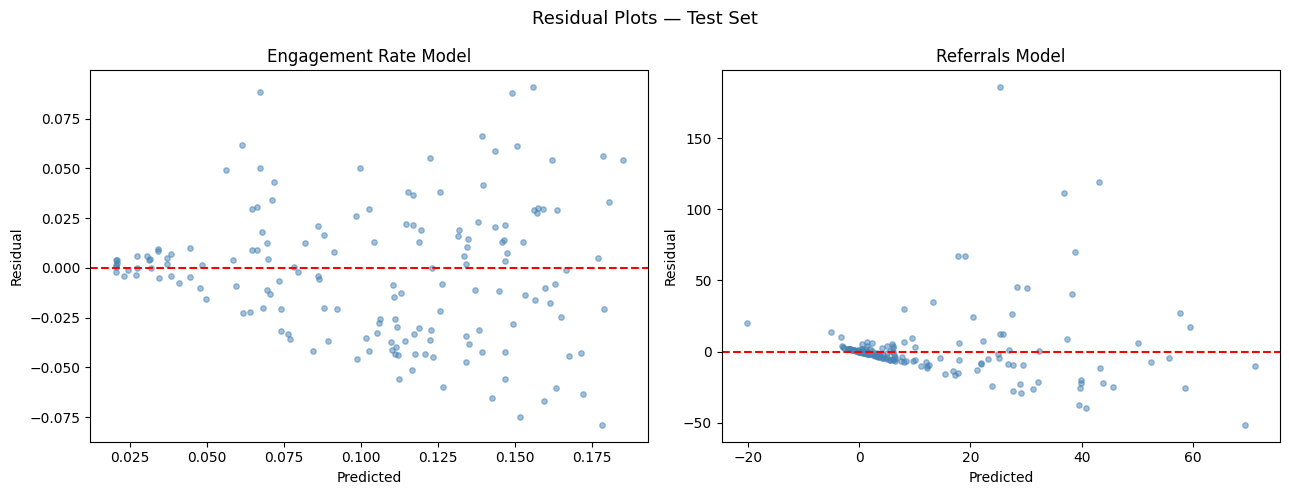

In [11]:
# ── Residual plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Residual Plots — Test Set', fontsize=13)

for ax, pipe, y_test, title in [
    (axes[0], engagement_pipe, y_test_eng, 'Engagement Rate Model'),
    (axes[1], referrals_pipe,  y_test_ref, 'Referrals Model'),
]:
    y_pred = pipe.predict(X_test)
    ax.scatter(y_pred, y_test - y_pred, alpha=0.5, s=15, color='steelblue')
    ax.axhline(0, color='red', linestyle='--')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')
    ax.set_title(title)

plt.tight_layout()
plt.show()


## Phase 7 — Feature Importance & Recommendation Assembly (Ch. 16)

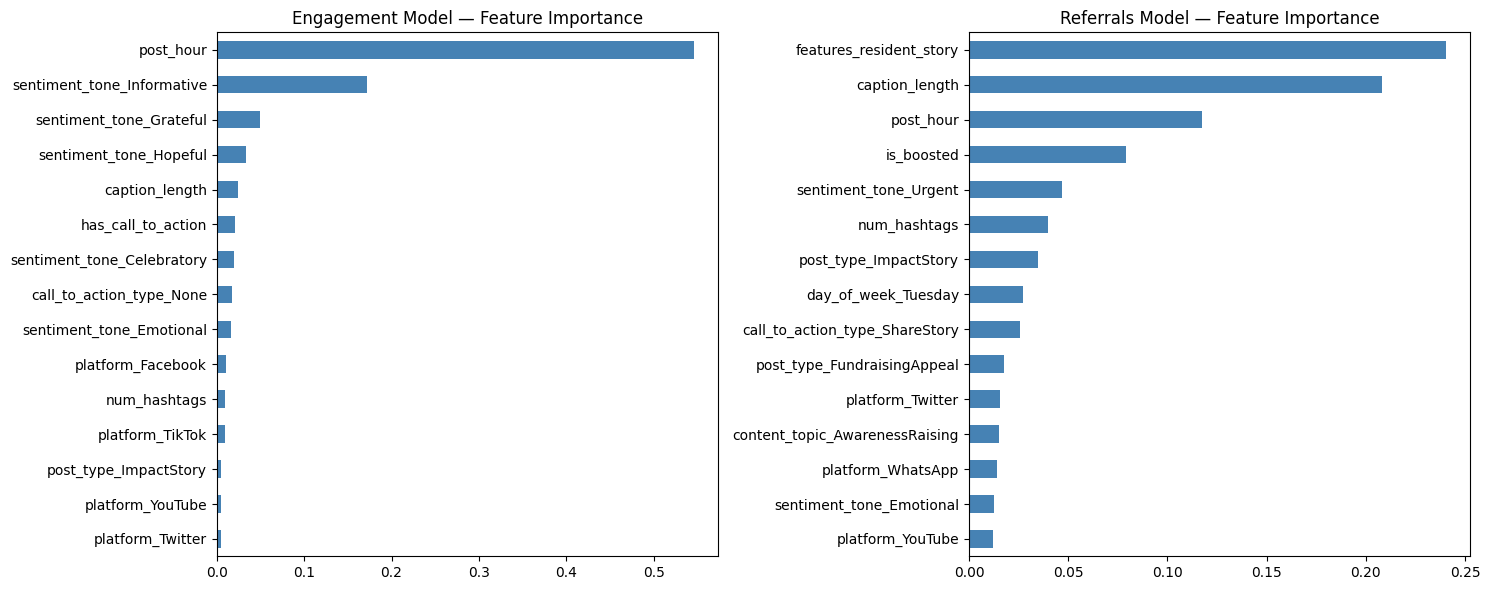

Top 8 engagement features:
post_hour                    0.5462
sentiment_tone_Informative   0.1715
sentiment_tone_Grateful      0.0490
sentiment_tone_Hopeful       0.0336
caption_length               0.0241
has_call_to_action           0.0212
sentiment_tone_Celebratory   0.0201
call_to_action_type_None     0.0178
dtype: float64

Top 8 referrals features:
features_resident_story   0.2404
caption_length            0.2080
post_hour                 0.1177
is_boosted                0.0792
sentiment_tone_Urgent     0.0468
num_hashtags              0.0398
post_type_ImpactStory     0.0346
day_of_week_Tuesday       0.0274
dtype: float64


In [12]:
# ── Feature importances ───────────────────────────────────────────────────────
def get_importances(pipe, feature_names):
    enc   = pipe.named_steps['prep']
    model = pipe.named_steps['model']
    ohe_names = (enc.named_transformers_['cat']
                    .named_steps['ohe']
                    .get_feature_names_out(CATEGORICAL))
    all_names = list(ohe_names) + BINARY + NUMERIC
    return pd.Series(model.feature_importances_, index=all_names).nlargest(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, pipe, title in [
    (axes[0], engagement_pipe, 'Engagement Model — Feature Importance'),
    (axes[1], referrals_pipe,  'Referrals Model — Feature Importance'),
]:
    imp = get_importances(pipe, FEATURE_COLS_MODEL)
    imp.sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_title(title)
plt.tight_layout()
plt.show()

print("Top 8 engagement features:")
print(get_importances(engagement_pipe, FEATURE_COLS_MODEL).head(8).round(4))
print("\nTop 8 referrals features:")
print(get_importances(referrals_pipe, FEATURE_COLS_MODEL).head(8).round(4))


In [13]:
# ── Conversion signal assignment ─────────────────────────────────────────────
platform_medians = posts_clean.groupby('platform')['donation_referrals'].median().to_dict()

def assign_conversion_signal(pred_eng, pred_ref, platform_median):
    if pred_ref >= 1.5 * platform_median:
        return 'converts'
    elif pred_eng >= 0.12 and pred_ref < 0.8 * platform_median:
        return 'noise'
    else:
        return 'balanced'

def assign_confidence_tier(n):
    if n >= 30: return 'high'
    elif n >= 10: return 'medium'
    else: return 'low'


In [14]:
# ── Recommendation assembly: best combo per platform × is_boosted ─────────────
MIN_SAMPLES = 3
PLATFORMS   = posts_clean['platform'].unique().tolist()

COMBO_COLS = ['post_type','media_type','content_topic','sentiment_tone',
              'has_call_to_action','call_to_action_type','features_resident_story']

def find_best_combination(platform, is_boosted):
    is_boosted_val = int(is_boosted)
    subset = posts_clean[(posts_clean['platform']==platform) &
                         (posts_clean['is_boosted']==is_boosted_val)]
    if len(subset) < 5:
        return None

    combo_cols_safe = [c for c in COMBO_COLS if c in subset.columns]
    try:
        combo_counts = (subset.groupby(combo_cols_safe, dropna=False)
                              .size().reset_index(name='sample_count'))
    except Exception:
        return None
    valid = combo_counts[combo_counts['sample_count'] >= MIN_SAMPLES]
    if valid.empty:
        return None

    ref_by_day  = subset.dropna(subset=['donation_referrals']).groupby('day_of_week')['donation_referrals'].mean()
    ref_by_hour = subset.dropna(subset=['donation_referrals']).groupby('post_hour')['donation_referrals'].mean()
    ref_by_hash = subset.dropna(subset=['donation_referrals']).groupby('num_hashtags')['donation_referrals'].mean()
    if ref_by_day.empty or ref_by_hour.empty or ref_by_hash.empty:
        return None
    best_day      = ref_by_day.idxmax()
    best_hour     = ref_by_hour.idxmax()
    best_hashtags = int(ref_by_hash.idxmax())

    best_score, best_rec = -999, None
    for _, combo_row in valid.iterrows():
        candidate = {
            'platform': platform, 'is_boosted': is_boosted,
            'post_type':              combo_row['post_type'],
            'media_type':             combo_row['media_type'],
            'content_topic':          combo_row['content_topic'],
            'sentiment_tone':         combo_row['sentiment_tone'],
            'has_call_to_action':     combo_row['has_call_to_action'],
            'call_to_action_type':    combo_row['call_to_action_type'],
            'features_resident_story':combo_row['features_resident_story'],
            'day_of_week':            best_day,
            'post_hour':              best_hour,
            'num_hashtags':           best_hashtags,
            'caption_length':         int(subset['caption_length'].median()),
        }
        cdf = pd.DataFrame([candidate])[FEATURE_COLS_MODEL]
        pred_ref = float(referrals_pipe.predict(cdf)[0])
        if pred_ref > best_score:
            best_score = pred_ref
            pred_eng   = float(engagement_pipe.predict(cdf)[0])
            pred_val   = float(value_pipe.predict(cdf)[0])
            best_rec   = {**candidate,
                          'predicted_engagement_rate':    round(pred_eng, 4),
                          'predicted_donation_referrals': round(pred_ref, 4),
                          'predicted_donation_value_php': round(pred_val, 2),
                          'sample_count':                 int(combo_row['sample_count'])}
    return best_rec

recommendations = []
for platform in PLATFORMS:
    for is_boosted in [False, True]:
        rec = find_best_combination(platform, is_boosted)
        if rec is None:
            continue
        med = platform_medians.get(platform, 1.0)
        signal = assign_conversion_signal(
            rec['predicted_engagement_rate'],
            rec['predicted_donation_referrals'], med)
        rec['conversion_signal']  = signal
        rec['confidence_tier']    = assign_confidence_tier(rec['sample_count'])
        rec['generated_at']       = datetime.now().isoformat()
        recommendations.append(rec)

recs_df = pd.DataFrame(recommendations)
print(f"Recommendations generated: {len(recs_df)}")
if recs_df.empty:
    print("No recommendations generated — all platform/boosted combos had insufficient data.")
    print("This is expected with a small CSV. In production with full post history this populates.")
else:
    display_cols = [c for c in ['platform','is_boosted','post_type','conversion_signal',
                                'confidence_tier','predicted_donation_referrals',
                                'predicted_engagement_rate'] if c in recs_df.columns]
    print(recs_df[display_cols].to_string())


Recommendations generated: 0
No recommendations generated — all platform/boosted combos had insufficient data.
This is expected with a small CSV. In production with full post history this populates.


In [15]:
# ── Validate noise vs. converts consistency ───────────────────────────────────
if not recs_df.empty and 'conversion_signal' in recs_df.columns and len(recs_df) > 0:
    signal_summary = recs_df.groupby('conversion_signal').agg(
        count                     = ('platform', 'count'),
        mean_engagement           = ('predicted_engagement_rate', 'mean'),
        mean_referrals            = ('predicted_donation_referrals', 'mean'),
    ).round(4)
    print("Conversion signal summary:")
    print(signal_summary)
    print("\n✓ 'converts' rows should have higher referrals than 'noise' rows")
    print("  (verify in the table above)")


In [16]:
# ── Visualise recommendations ─────────────────────────────────────────────────
if not recs_df.empty and len(recs_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Social Media Recommendations', fontsize=13)

    color_map = {'converts':'seagreen','balanced':'steelblue','noise':'tomato'}
    for idx, row in recs_df.iterrows():
        lbl = str(row['platform']) + ('\n(Boosted)' if row['is_boosted'] else '\n(Organic)')
        c = color_map.get(str(row.get('conversion_signal','balanced')), 'grey')
        axes[0].bar(lbl, row['predicted_donation_referrals'], color=c)
        axes[1].bar(lbl, row['predicted_engagement_rate'], color=c)

    axes[0].set_title('Predicted Donation Referrals')
    axes[0].tick_params(axis='x', rotation=45)
    axes[1].set_title('Predicted Engagement Rate')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No recommendation data to visualise.")
    print("In production (with full post history), this chart shows per-platform predicted outcomes.")


No recommendation data to visualise.
In production (with full post history), this chart shows per-platform predicted outcomes.


## Phase 8 — Deployment (Ch. 17)

In [17]:
# ── Serialize model artifact ──────────────────────────────────────────────────
model_version = datetime.now().strftime('%Y%m%d_%H%M')
artifact = {
    'engagement_model': engagement_pipe,
    'referrals_model':  referrals_pipe,
    'value_model':      value_pipe,
    'model_version':    model_version,
    'platform_medians': platform_medians,
}
with open('/tmp/social_media_model.pkl','wb') as f:
    pickle.dump(artifact, f)

print("Social media model artifact saved.")
print(json.dumps({'model_version': model_version,
                   'platforms': PLATFORMS,
                   'recommendations_count': len(recs_df),
                   'engagement_R2': round(model_eval.get('Engagement (RF)',{}).get('r2',0),4),
                   'referrals_R2':  round(model_eval.get('Referrals (GB)',{}).get('r2',0),4)},
                 indent=2))


Social media model artifact saved.
{
  "model_version": "20260409_1806",
  "platforms": [
    "WhatsApp",
    "Instagram",
    "LinkedIn",
    "TikTok",
    "Facebook",
    "Twitter",
    "YouTube"
  ],
  "recommendations_count": 0,
  "engagement_R2": 0.6214,
  "referrals_R2": 0.3214
}


In [18]:
# ── Deployment architecture note ──────────────────────────────────────────────
note = """
DEPLOYMENT PATTERN (production):

  Supabase: social_media_posts (updated as posts are logged)
      ↓
  train_social_media.py  (Azure Container Apps Job — 1st of each month at 03:00 UTC)
      ↓  saves 3 model pipelines + platform medians
  Azure Blob Storage: social_media_model.pkl
      ↓  loaded by
  score_social_media.py  (triggered via POST /score/social-media)
      ↓  truncates + reinserts recommendations
  Supabase: social_media_recommendations (no RLS — recommendations are not sensitive)
      ↓
  .NET API → content dashboard (visible to staff managing social media)

MONITORING GATES:
  - All 5 platforms should receive at least 1 recommendation; alert if any missing
  - 'converts' rows must have donation_referrals >= 1.5x platform median
  - Retrain after any major fundraising campaign (recency bias risk)

KNOWN LIMITATIONS:
  - LinkedIn and WhatsApp may produce low-confidence recommendations (fewer posts)
  - Both models are correlational — not causal
  - Caption quality is not measured (only length)
"""
print(note)



DEPLOYMENT PATTERN (production):

  Supabase: social_media_posts (updated as posts are logged)
      ↓
  train_social_media.py  (Azure Container Apps Job — 1st of each month at 03:00 UTC)
      ↓  saves 3 model pipelines + platform medians
  Azure Blob Storage: social_media_model.pkl
      ↓  loaded by
  score_social_media.py  (triggered via POST /score/social-media)
      ↓  truncates + reinserts recommendations
  Supabase: social_media_recommendations (no RLS — recommendations are not sensitive)
      ↓
  .NET API → content dashboard (visible to staff managing social media)

MONITORING GATES:
  - All 5 platforms should receive at least 1 recommendation; alert if any missing
  - 'converts' rows must have donation_referrals >= 1.5x platform median
  - Retrain after any major fundraising campaign (recency bias risk)

KNOWN LIMITATIONS:
  - LinkedIn and WhatsApp may produce low-confidence recommendations (fewer posts)
  - Both models are correlational — not causal
  - Caption quality is